In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.DataFrame({
    'x': [1, 2, 3, 4, 5, 6, 7],
    'y': [0, 0, 0, 1, 1, 1, 1]
})

In [5]:
df

,x,y
0,1,0
1,2,0
2,3,0
3,4,1
4,5,1
5,6,1
6,7,1


In [28]:
study_hours = df[['x']]
result = df[['y']]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
study_hours = study_hours.values
result = result.values
study_hours, result

(array([[1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7]], dtype=int64),
 array([[0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1]], dtype=int64))

In [12]:
x = np.c_[np.ones(len(study_hours)), study_hours]
y = result

In [13]:
m = np.linalg.pinv(x.T @ x) @ (x.T @ y)

In [14]:
m

array([[-0.28571429],
       [ 0.21428571]])

In [15]:
a0, a1 = m
# lin reg, equation
def z(x):
    return a0 + a1*x

In [16]:
def sigmoid(x):
    return 1 / (1 + np.exp(-z(x)))

In [19]:
res = sigmoid(10)[0]

In [21]:
res

0.8649635770771977

In [22]:
'pass' if res > 0.5 else 'fail'

'pass'

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = LogisticRegression()

In [33]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(study_hours, result)

In [34]:
model.fit(xtrain, ytrain)

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [49]:
y_pred = model.predict(xtest)

In [37]:
xtest

,x
6,7
1,2


In [38]:
x_testing = pd.DataFrame({
    'x': [7, 10, 2, 0, 1, 12]
})

In [39]:
model.predict(x_testing)

array([1, 1, 0, 0, 0, 1], dtype=int64)

In [41]:
tests = sigmoid(x_testing)

In [42]:
tests

,x
0,0.771056
1,0.864964
2,0.535654
3,0.429053
4,0.482150
5,0.907687


In [43]:
threshold = 0.6

In [47]:
tests['res'] = (tests["x"] >= threshold).astype(int)

In [48]:
tests

,x,res
0,0.771056,1
1,0.864964,1
2,0.535654,0
3,0.429053,0
4,0.482150,0
5,0.907687,1


In [50]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytest, y_pred)
print(acc)

1.0


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ytest, y_pred)
print(cm)

[[1 0]
 [0 1]]


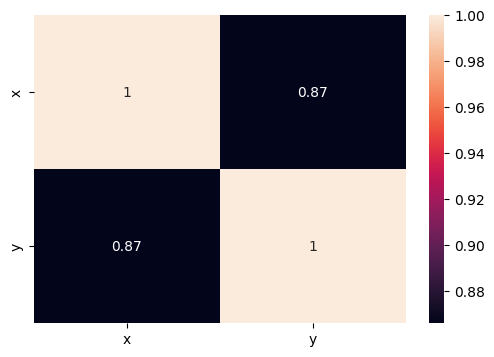

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.show()

In [55]:
X_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)

In [56]:
y_prob = model.predict_proba(X_range)[:, 1]

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


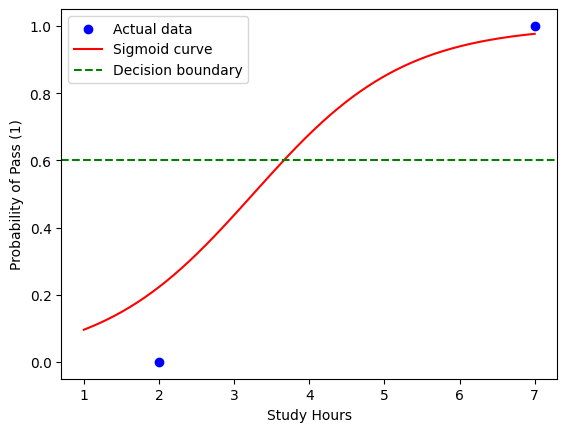

In [61]:
plt.scatter(xtest, ytest, color='blue', label="Actual data")

plt.plot(X_range, y_prob, color='red', label="Sigmoid curve")

plt.axhline(threshold, color='green', linestyle='--', label="Decision boundary")

plt.xlabel("Study Hours")
plt.ylabel("Probability of Pass (1)")
plt.legend()
plt.show()

C:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


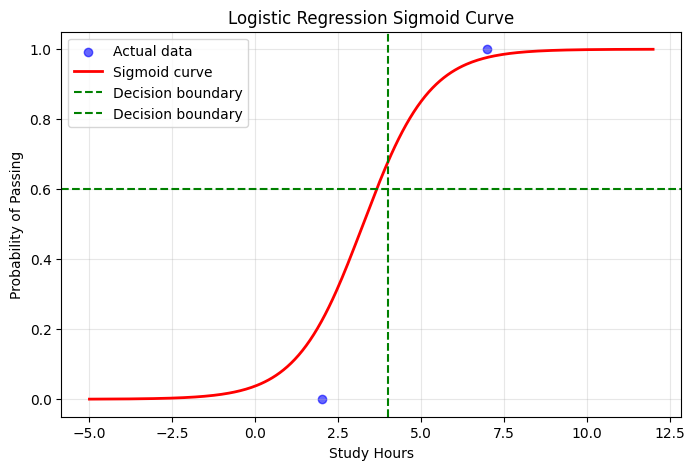

In [68]:
plt.figure(figsize=(8,5))

# actual points (slightly transparent for better view)
plt.scatter(xtest, ytest, color='blue', alpha=0.6, label="Actual data")

# smooth sigmoid curve
X_range = np.linspace(-5, x_testing.max(), 300).reshape(-1, 1)
y_prob = model.predict_proba(X_range)[:, 1]

plt.plot(X_range, y_prob, color='red', linewidth=2, label="Sigmoid curve")

# decision boundary
threshold = 0.6
plt.axhline(threshold, color='green', linestyle='--', linewidth=1.5, label="Decision boundary")
plt.axvline(4, color='green', linestyle='--', linewidth=1.5, label="Decision boundary")

# styling
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Sigmoid Curve")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [69]:
def cost_function(y_true, y_pred):
    m = len(y_true)
    return np.sum((y_pred - y_true) ** 2) / m

In [73]:
yp = model.predict(xtest)
# cost_function(ytest, yp)
yp

array([1, 0], dtype=int64)

In [76]:
xtest['x'].values

array([7, 2], dtype=int64)

In [78]:
cost_function(ytest['y'].values, yp)

0.0